# E36 — A janela que se escolhe sozinha

O tamanho da memória decidido pelo dado: o teste das metades derruba a metade velha quando as
duas discordam além de um limiar. **Regras declaradas antes da prosa** (ver docstring do
construtor): limiar calibrado no parado com orçamento de falsos; três critérios de separação;
controle estrutural no módulo. Nada de número sem dispersão junto.

In [1]:
import sys
sys.path.insert(0, "lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from frevolab import adaptativa, dados, esquecimento, graficos, mudanca

SEMENTE = 103            # <- brinque com:
MUNDOS = 24              # mundos medidos
MUNDOS_CALIBRACAO = 8    # mundos do parado para o limiar (decisão, não medição)
DIAS = 14000
QUANDO_MUDANCA = 4000
FATOR = 2.0
SIGMA = mudanca.SIGMA_PADRAO
VERDADE_BASE = SIGMA * np.sqrt(2.0 / np.pi)
MINIMA = 21              # a memória vencedora do capítulo do esquecimento
MAXIMA = 1008
JANELA_LONGA = 252
JANELA_CURTA = 50
TAXA_MISTURA = round(1.0 / 21.0, 4)   # a mistura exponencial da memória de 21 dias
ORCAMENTO_FALSOS_POR_ANO = 1.0

print("frevolab", __import__("frevolab").VERSAO, "| mundos", MUNDOS, "| minima", MINIMA, "| maxima", MAXIMA)

frevolab 0.1.0 | mundos 24 | minima 21 | maxima 1008


In [2]:
# Os mundos: o valor absoluto dos retornos, como o caderno do esquecimento; a verdade é o nível
# de cada pedaço (sigma pela raiz de dois sobre pi, dobrado depois da mudança).
SORTEIO = np.random.default_rng(SEMENTE)
PARADOS = [np.abs(mudanca.estavel(DIAS, SORTEIO)) for _ in range(MUNDOS)]
DEGRAUS = [np.abs(mudanca.degrau(DIAS, SORTEIO, fator=FATOR, quando=QUANDO_MUDANCA)) for _ in range(MUNDOS)]
VERDADE_DEGRAU = np.array([VERDADE_BASE * (FATOR if t >= QUANDO_MUDANCA else 1.0) for t in range(DIAS)])
VERDADE_PARADO = np.full(DIAS, VERDADE_BASE)
print("mundos prontos:", len(PARADOS) + len(DEGRAUS))

mundos prontos: 48


In [3]:
# A calibração do limiar: DECISÃO antes da medição. Grade no parado, o menor limiar que respeita o
# orçamento de um encolhimento falso por ano (mediana dos mundos de calibração).
LIMIARES = (0.0006, 0.0008, 0.0010, 0.0014, 0.002, 0.003, 0.004, 0.005, 0.007, 0.010, 0.015, 0.025)
tabela = []
for limiar in LIMIARES:
    falsos = [adaptativa.falsos_por_ano(adaptativa.nivel(s, limiar, MINIMA, MAXIMA)["encolhimentos"], DIAS)
              for s in PARADOS[:MUNDOS_CALIBRACAO]]
    tabela.append((limiar, float(np.median(falsos))))
    print("limiar %.4f | falsos/ano (mediana) %.3f" % (limiar, tabela[-1][1]))
LIMIAR_ORCADO = min(l for l, f in tabela if f <= ORCAMENTO_FALSOS_POR_ANO)
print("LIMIAR ORCADO:", LIMIAR_ORCADO, "(um falso por ano no máximo, no parado)")

limiar 0.0006 | falsos/ano (mediana) 11.718
limiar 0.0008 | falsos/ano (mediana) 11.484
limiar 0.0010 | falsos/ano (mediana) 10.989


limiar 0.0014 | falsos/ano (mediana) 0.990
limiar 0.0020 | falsos/ano (mediana) 0.063


limiar 0.0030 | falsos/ano (mediana) 0.009
limiar 0.0040 | falsos/ano (mediana) 0.000


limiar 0.0050 | falsos/ano (mediana) 0.000
limiar 0.0070 | falsos/ano (mediana) 0.000


limiar 0.0100 | falsos/ano (mediana) 0.000
limiar 0.0150 | falsos/ano (mediana) 0.000


limiar 0.0250 | falsos/ano (mediana) 0.000
LIMIAR ORCADO: 0.0014 (um falso por ano no máximo, no parado)


In [4]:
# O degrau: cinco concorrentes, a moeda do caderno do esquecimento (erro relativo médio contra a
# verdade no ANO seguinte à mudança), mediana e dispersão entre mundos. A janela de mil e oito é o
# teto da adaptativa --- o controle estrutural: sem encolher, é ela que a adaptativa seria.
INICIO = QUANDO_MUDANCA
HORIZONTE = 252

ERROS = {"janela_longa": [], "janela_curta": [], "mistura": [], "teto": [], "adaptativa": []}
for s in DEGRAUS:
    ERROS["janela_longa"].append(esquecimento.erro(esquecimento.janela(s, JANELA_LONGA), VERDADE_DEGRAU,
                                                   inicio=INICIO, horizonte=HORIZONTE))
    ERROS["janela_curta"].append(esquecimento.erro(esquecimento.janela(s, JANELA_CURTA), VERDADE_DEGRAU,
                                                   inicio=INICIO, horizonte=HORIZONTE))
    ERROS["mistura"].append(esquecimento.erro(esquecimento.exponencial(s, TAXA_MISTURA), VERDADE_DEGRAU,
                                              inicio=INICIO, horizonte=HORIZONTE))
    ERROS["teto"].append(esquecimento.erro(esquecimento.janela(s, MAXIMA), VERDADE_DEGRAU,
                                           inicio=INICIO, horizonte=HORIZONTE))
    ERROS["adaptativa"].append(esquecimento.erro(adaptativa.nivel(s, LIMIAR_ORCADO, MINIMA, MAXIMA)["estimativa"],
                                                 VERDADE_DEGRAU, inicio=INICIO, horizonte=HORIZONTE))
DEGRAU_RESUMO = {nome: {"mediana": float(np.median(v)), "dispersao": float(np.std(v, ddof=1))}
                 for nome, v in ERROS.items()}
for nome, r in DEGRAU_RESUMO.items():
    print("%12s | erro %.4f (disp %.4f)" % (nome, r["mediana"], r["dispersao"]))

janela_longa | erro 0.2609 (disp 0.0336)
janela_curta | erro 0.1251 (disp 0.0174)
     mistura | erro 0.1213 (disp 0.0171)
        teto | erro 0.4413 (disp 0.0149)
  adaptativa | erro 0.2405 (disp 0.0391)


In [5]:
# O parado: o preço de deixar o dado escolher quando nada muda --- erro contra a janela longa, e
# a contagem de falsos por ano no limiar orcado.
PARADO_RESUMO = {}
erros_adapt = [esquecimento.erro(adaptativa.nivel(s, LIMIAR_ORCADO, MINIMA, MAXIMA)["estimativa"], VERDADE_PARADO,
                                   inicio=MAXIMA, horizonte=DIAS - MAXIMA)
               for s in PARADOS]
erros_longa = [esquecimento.erro(esquecimento.janela(s, MAXIMA), VERDADE_PARADO,
                                 inicio=MAXIMA, horizonte=DIAS - MAXIMA) for s in PARADOS]
falsos_todos = [adaptativa.falsos_por_ano(adaptativa.nivel(s, LIMIAR_ORCADO, MINIMA, MAXIMA)["encolhimentos"], DIAS)
                for s in PARADOS]
PARADO_RESUMO = {"erro_adaptativa_mediana": float(np.median(erros_adapt)),
                 "erro_adaptativa_dispersao": float(np.std(erros_adapt, ddof=1)),
                 "erro_janela_teto_mediana": float(np.median(erros_longa)),
                 "erro_janela_teto_dispersao": float(np.std(erros_longa, ddof=1)),
                 "falsos_por_ano_mediana": float(np.median(falsos_todos)),
                 "falsos_por_ano_pior": float(np.max(falsos_todos))}
for chave, valor in PARADO_RESUMO.items():
    print("%28s %.4f" % (chave, valor))

     erro_adaptativa_mediana 0.0228
   erro_adaptativa_dispersao 0.0066
    erro_janela_teto_mediana 0.0191
  erro_janela_teto_dispersao 0.0032
      falsos_por_ano_mediana 0.6750
         falsos_por_ano_pior 2.3040


In [6]:
# As séries reais: descritivo §8.5. A cadência de encolhimentos por ano e a trajetória do tamanho.
RETORNOS_REAIS = {}
for nome, arquivo in (("sp", "sp500.csv"), ("ibov", "ibov.csv"), ("btc", "btc.csv")):
    preco = dados.carregar_serie(arquivo)
    RETORNOS_REAIS[nome] = np.abs(preco.pct_change().dropna().to_numpy())
    caixa = adaptativa.nivel(RETORNOS_REAIS[nome], LIMIAR_ORCADO, MINIMA, MAXIMA)
    anos = RETORNOS_REAIS[nome].size / 252.0
    print("%4s | %5d dias | %3d encolhimentos | %.2f por ano | tamanho final %d" % (
        nome, RETORNOS_REAIS[nome].size, len(caixa["encolhimentos"]),
        len(caixa["encolhimentos"]) / anos, caixa["tamanhos"][-1]))

  sp |  6718 dias | 212 encolhimentos | 7.95 por ano | tamanho final 33
ibov |  6620 dias | 278 encolhimentos | 10.58 por ano | tamanho final 35
 btc |  4387 dias | 206 encolhimentos | 11.83 por ano | tamanho final 32


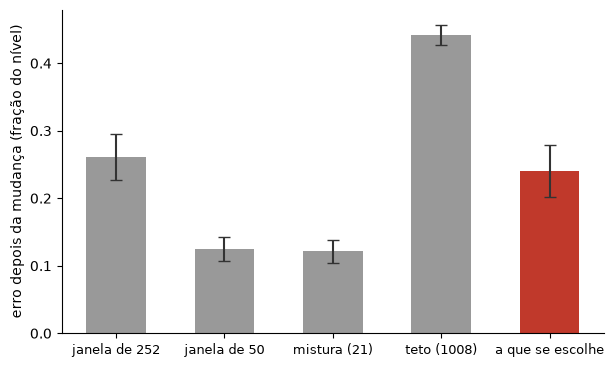

In [7]:
# Figura 1: o erro depois do degrau, mediana e dispersão entre mundos, quatro concorrentes.
fig, ax = plt.subplots(figsize=(7.0, 4.2))
nomes = ["janela_longa", "janela_curta", "mistura", "teto", "adaptativa"]
rotulos = ["janela de 252", "janela de 50", "mistura (21)", "teto (1008)", "a que se escolhe"]
xs = np.arange(len(nomes))
medianas = [DEGRAU_RESUMO[n]["mediana"] for n in nomes]
dispersoes = [DEGRAU_RESUMO[n]["dispersao"] for n in nomes]
ax.bar(xs, medianas, width=0.55, color=["0.6", "0.6", "0.6", "0.6", "#c0392b"])
ax.errorbar(xs, medianas, yerr=dispersoes, fmt="none", ecolor="0.2", capsize=4)
ax.set_xticks(xs)
ax.set_xticklabels(rotulos, fontsize=9)
ax.set_ylabel("erro depois da mudança (fração do nível)")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E36_adaptativa", 1)
plt.show()

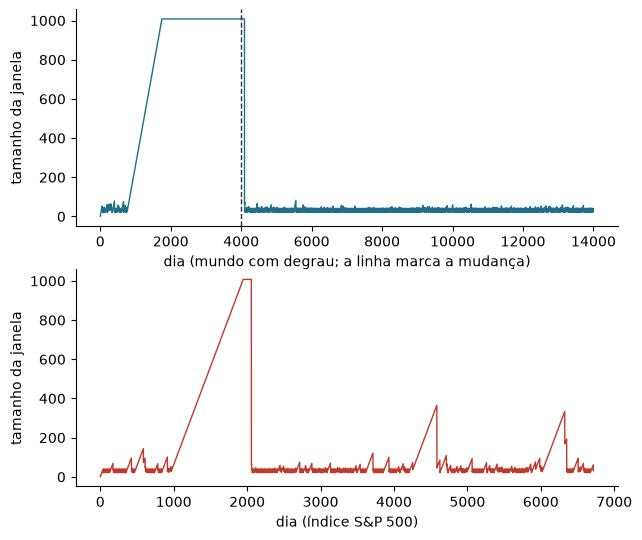

In [8]:
# Figura 2: o tamanho que o dado escolhe, ao longo do tempo --- num mundo com degrau (a mudança
# marcada) e na série real do índice.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 6.2))
caixa_mundo = adaptativa.nivel(DEGRAUS[0], LIMIAR_ORCADO, MINIMA, MAXIMA)
ax1.plot(caixa_mundo["tamanhos"], color="#1f6f8b", linewidth=1.0)
ax1.axvline(QUANDO_MUDANCA, color="0.2", linestyle="--", linewidth=1.0)
ax1.set_ylabel("tamanho da janela")
ax1.set_xlabel("dia (mundo com degrau; a linha marca a mudança)")
ax1.spines[["top", "right"]].set_visible(False)
caixa_real = adaptativa.nivel(RETORNOS_REAIS["sp"], LIMIAR_ORCADO, MINIMA, MAXIMA)
ax2.plot(caixa_real["tamanhos"], color="#c0392b", linewidth=1.0)
ax2.set_ylabel("tamanho da janela")
ax2.set_xlabel("dia (índice S&P 500)")
ax2.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E36_adaptativa", 2)
plt.show()

In [9]:
CAIXAS_DEGRAU = [adaptativa.nivel(s, LIMIAR_ORCADO, MINIMA, MAXIMA) for s in DEGRAUS]
DEGRAU_CORTES_POR_ANO = float(np.median([len(c["encolhimentos"]) * 252.0 / DIAS for c in CAIXAS_DEGRAU]))
DEGRAU_TAMANHO_MEDIO = float(np.median([np.mean(c["tamanhos"][QUANDO_MUDANCA:]) for c in CAIXAS_DEGRAU]))
DEGRAU_TAMANHO_ANTES = float(np.median([c["tamanhos"][QUANDO_MUDANCA - 1] for c in CAIXAS_DEGRAU]))
print("degrau: cortes/ano %.2f | tamanho medio pos %.1f | tamanho antes %.1f" % (
    DEGRAU_CORTES_POR_ANO, DEGRAU_TAMANHO_MEDIO, DEGRAU_TAMANHO_ANTES))

# Leitura visual das figuras (declaratória, contra o PNG):
# 1) ...
# 2) ...

degrau: cortes/ano 8.72 | tamanho medio pos 40.8 | tamanho antes 1008.0


In [10]:
# O que sai do laboratório e o que o livro cita.
anos_reais = {nome: serie.size / 252.0 for nome, serie in RETORNOS_REAIS.items()}
cadencias = {}
for nome, serie in RETORNOS_REAIS.items():
    caixa = adaptativa.nivel(serie, LIMIAR_ORCADO, MINIMA, MAXIMA)
    cadencias[nome] = len(caixa["encolhimentos"]) / anos_reais[nome]
tamanhos_finais = {nome: int(adaptativa.nivel(serie, LIMIAR_ORCADO, MINIMA, MAXIMA)["tamanhos"][-1])
                   for nome, serie in RETORNOS_REAIS.items()}

resultado = {
    "adaptativa_mundos": int(MUNDOS),
    "adaptativa_dias": int(DIAS),
    "adaptativa_quando_mudanca": int(QUANDO_MUDANCA),
    "adaptativa_fator": float(FATOR),
    "adaptativa_minima": int(MINIMA),
    "adaptativa_maxima": int(MAXIMA),
    "adaptativa_limiar_orcado": round(float(LIMIAR_ORCADO), 4),
    "adaptativa_orcamento_falsos_por_ano": float(ORCAMENTO_FALSOS_POR_ANO),
    "adaptativa_degrau_erro_janela_longa_mediana": round(DEGRAU_RESUMO["janela_longa"]["mediana"], 4),
    "adaptativa_degrau_erro_janela_longa_dispersao": round(DEGRAU_RESUMO["janela_longa"]["dispersao"], 4),
    "adaptativa_degrau_erro_janela_curta_mediana": round(DEGRAU_RESUMO["janela_curta"]["mediana"], 4),
    "adaptativa_degrau_erro_janela_curta_dispersao": round(DEGRAU_RESUMO["janela_curta"]["dispersao"], 4),
    "adaptativa_degrau_erro_mistura_mediana": round(DEGRAU_RESUMO["mistura"]["mediana"], 4),
    "adaptativa_degrau_erro_mistura_dispersao": round(DEGRAU_RESUMO["mistura"]["dispersao"], 4),
    "adaptativa_degrau_erro_mediana": round(DEGRAU_RESUMO["adaptativa"]["mediana"], 4),
    "adaptativa_degrau_erro_dispersao": round(DEGRAU_RESUMO["adaptativa"]["dispersao"], 4),
    "adaptativa_parado_erro_adaptativa_mediana": round(PARADO_RESUMO["erro_adaptativa_mediana"], 4),
    "adaptativa_parado_erro_adaptativa_dispersao": round(PARADO_RESUMO["erro_adaptativa_dispersao"], 4),
    "adaptativa_parado_erro_janela_teto_mediana": round(PARADO_RESUMO["erro_janela_teto_mediana"], 4),
    "adaptativa_parado_erro_janela_teto_dispersao": round(PARADO_RESUMO["erro_janela_teto_dispersao"], 4),
    "adaptativa_degrau_erro_teto_mediana": round(DEGRAU_RESUMO["teto"]["mediana"], 4),
    "adaptativa_degrau_erro_teto_dispersao": round(DEGRAU_RESUMO["teto"]["dispersao"], 4),
    "adaptativa_parado_falsos_por_ano_mediana": round(PARADO_RESUMO["falsos_por_ano_mediana"], 3),
    "adaptativa_parado_falsos_por_ano_pior": round(PARADO_RESUMO["falsos_por_ano_pior"], 3),
    "adaptativa_real_sp_encolhimentos_por_ano": round(cadencias["sp"], 2),
    "adaptativa_real_ibov_encolhimentos_por_ano": round(cadencias["ibov"], 2),
    "adaptativa_real_btc_encolhimentos_por_ano": round(cadencias["btc"], 2),
    "adaptativa_real_sp_dias": int(RETORNOS_REAIS["sp"].size),
    "adaptativa_real_sp_tamanho_final": tamanhos_finais["sp"],
    "adaptativa_real_btc_tamanho_final": tamanhos_finais["btc"],
    "adaptativa_taxa_mistura": float(TAXA_MISTURA),
    "adaptativa_degrau_encolhimentos_por_ano": round(DEGRAU_CORTES_POR_ANO, 2),
    "adaptativa_degrau_tamanho_medio_pos": round(DEGRAU_TAMANHO_MEDIO, 1),
    "adaptativa_degrau_tamanho_antes": round(DEGRAU_TAMANHO_ANTES, 1),
}

CITADAS_NO_LIVRO = tuple(sorted(resultado))
resultado = {k: v for k, v in resultado.items() if k in CITADAS_NO_LIVRO}
import json
from pathlib import Path
caminho = Path("lab/resultados/E36_adaptativa.json")
caminho.write_text(json.dumps(resultado, indent=1, ensure_ascii=False, sort_keys=True), encoding="utf-8")
print(json.dumps(resultado, ensure_ascii=False, indent=1, sort_keys=True))

{
 "adaptativa_degrau_encolhimentos_por_ano": 8.72,
 "adaptativa_degrau_erro_dispersao": 0.0391,
 "adaptativa_degrau_erro_janela_curta_dispersao": 0.0174,
 "adaptativa_degrau_erro_janela_curta_mediana": 0.1251,
 "adaptativa_degrau_erro_janela_longa_dispersao": 0.0336,
 "adaptativa_degrau_erro_janela_longa_mediana": 0.2609,
 "adaptativa_degrau_erro_mediana": 0.2405,
 "adaptativa_degrau_erro_mistura_dispersao": 0.0171,
 "adaptativa_degrau_erro_mistura_mediana": 0.1213,
 "adaptativa_degrau_erro_teto_dispersao": 0.0149,
 "adaptativa_degrau_erro_teto_mediana": 0.4413,
 "adaptativa_degrau_tamanho_antes": 1008.0,
 "adaptativa_degrau_tamanho_medio_pos": 40.8,
 "adaptativa_dias": 14000,
 "adaptativa_fator": 2.0,
 "adaptativa_limiar_orcado": 0.0014,
 "adaptativa_maxima": 1008,
 "adaptativa_minima": 21,
 "adaptativa_mundos": 24,
 "adaptativa_orcamento_falsos_por_ano": 1.0,
 "adaptativa_parado_erro_adaptativa_dispersao": 0.0066,
 "adaptativa_parado_erro_adaptativa_mediana": 0.0228,
 "adaptativa_pa